针对笔记01_01中的问题,交易量无法被直接利用.大体呈现两个问题:  
1.时间通常是间隔一个月的,由于主力合约的存在,交易量通常集中在1,3,5,7...月,大体呈现先这样的规律  
2.并不是完全遵照一个月大,一个月小的规律,可能两个主力合约之间相差3个月  
3.2017-2020年之间的交易量相比2008-2017,2020-2026年间的交易量更加大

因此我们首先采取以下方式:  
1.采用滑动窗口,由于金融行为具有时效性,我们应该强调最近的时间,因此应该采用EWM指数加权平均法.  
2.指数平均发找到一个适合的周期.探究它们在金融中的作用,并用数据验证它们的相关性.  
3.针对交易量不一样的情况,我基于笔记01_01的判断,认为交易量只是说明了人们的分歧加大,交易行为上升,代表着更强的情绪,交易量本身对黄金的供需关系不应产生影响,只是放大某一方面的趋势.因此,应该采用一种相对比值变化而非绝对值作为一个价格预测的因子.

此外,由于我们把滚动窗口内的成交量看作是情绪的因子,那么我们也应该把 **价格波动** 结合起来,一起作为一个简易的情绪因子来分析.

黄金的供需关系,在短期内可能会因为突发事件,如  
1.战争爆发  
2.油价变化  
3.加息预期  
等突然改变供需关系.如果是用以往的数据来预测,那必须是针对进入了某一段时间的 **趋势** 才能进行.为了体现趋势的时间,也为了强调突发事件的影响,我们应该选择一个合适的 **滑动窗口** 

此外,黄金价格的变化,不一定在一天之内完全被定价,因此,研究一下黄金成交量与价格变化是否存在一个滞后的关系?  
当天的收盘价和几天后的收盘价,与黄金期货的成交量,哪一个关系更加紧密一点?

### 步骤一  
#### 处理交易量

成交量月数据如图所示
  ![成交量月数据](../../src/pic/成交量月数据.png)


首先,我们根据6个月作为窗口,取平均值,根据成交量的历史百分值判断相对的成交热情.

In [33]:
from utils.common import *

In [34]:
gold_future = pd.read_pickle('src/pickle/gold_future.pkl')

In [35]:
display(gold_future.head(10))

,Open,Close,High,Low,Volume
Date,,,,,
2012-05-09,1595.300049,1593.699951,1595.300049,1586.300049,30
2012-05-10,1594.199951,1595.099976,1595.099976,1592.400024,6
2012-05-11,1586.099976,1583.599976,1589.599976,1583.599976,6
2012-05-14,1563.000000,1560.599976,1563.099976,1555.500000,5
2012-05-15,1555.400024,1556.800049,1558.300049,1542.400024,28
2012-05-16,1541.400024,1536.199951,1541.400024,1528.500000,26
2012-05-17,1546.900024,1574.500000,1579.000000,1546.900024,51
2012-05-18,1573.699951,1591.599976,1591.599976,1568.199951,26
2012-05-21,1591.900024,1588.400024,1594.099976,1588.400024,32


In [36]:
gold_future_volume_monthly = gold_future['Volume'].resample("M").sum()
display(gold_future_volume_monthly.head(10))

/var/folders/nm/mph7gkl57w5_rd8w9fgp9c5r0000gp/T/ipykernel_1751/3503122086.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  gold_future_volume_monthly = gold_future['Volume'].resample("M").sum()


Date
2012-05-31    345111
2012-06-30     11162
2012-07-31    257528
2012-08-31     11783
2012-09-30     25557
2012-10-31      2244
2012-11-30    345777
2012-12-31      7061
2013-01-31    197723
2013-02-28     11784
Freq: ME, Name: Volume, dtype: int64

In [37]:
avg_volume = gold_future_volume_monthly.rolling(window=6).mean()
display(avg_volume)

Date
2012-05-31             NaN
2012-06-30             NaN
2012-07-31             NaN
2012-08-31             NaN
2012-09-30             NaN
                  ...     
2026-03-31    86441.000000
2026-04-30    81774.166667
2026-05-31    71008.833333
2026-06-30    71872.666667
2026-07-31    46430.666667
Freq: ME, Name: Volume, Length: 171, dtype: float64

<Axes: xlabel='Date', ylabel='Volume'>

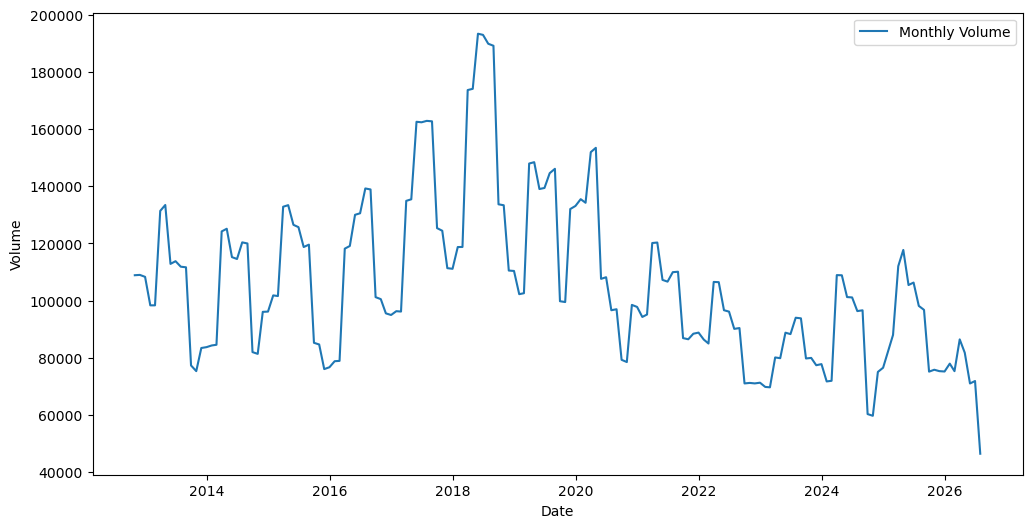

In [38]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data=avg_volume, label='Monthly Volume')

波动偏大,取6实际上基本取了三个柱子,再取12

<Axes: xlabel='Date', ylabel='Volume'>

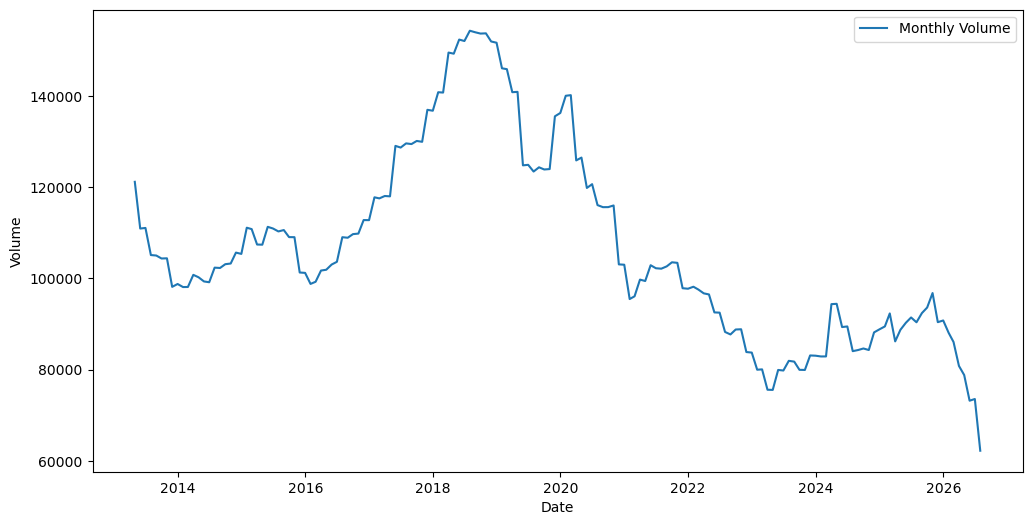

In [39]:
avg_volume = gold_future_volume_monthly.rolling(window=12).mean()
fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data=avg_volume, label='Monthly Volume')

新添加一行,作为这个数据在历史数据中的百分位

In [40]:
display(avg_volume)
# avg_volume.dropna(inplace=True)

Date
2012-05-31             NaN
2012-06-30             NaN
2012-07-31             NaN
2012-08-31             NaN
2012-09-30             NaN
                  ...     
2026-03-31    80796.833333
2026-04-30    78797.500000
2026-05-31    73169.416667
2026-06-30    73538.333333
2026-07-31    62193.833333
Freq: ME, Name: Volume, Length: 171, dtype: float64

In [41]:
avg_volume = pd.DataFrame(avg_volume)
avg_volume['pct_rank'] = avg_volume['Volume'].rank(pct=True)
display(avg_volume)

,Volume,pct_rank
Date,,
2012-05-31,NaN,NaN
2012-06-30,NaN,NaN
2012-07-31,NaN,NaN
2012-08-31,NaN,NaN
2012-09-30,NaN,NaN
...,...,...
2026-03-31,80796.833333,0.08125
2026-04-30,78797.500000,0.03750
2026-05-31,73169.416667,0.01250


之后以12个月为基础的窗口得到的平均值百分比来判断当前的情绪.  
接下来用指数加权处理.span不确定用多少比较好,用5,10,20三者进行比较

In [42]:
# exp_volume_5 = gold_future_volume_monthly.ewm(span=5, adjust=False).mean()
# exp_volume_10 = gold_future_volume_monthly.ewm(span=10, adjust=False).mean()
# exp_volume_20 = gold_future_volume_monthly.ewm(span=20, adjust=False).mean()
display(exp_volume_5)
display(exp_volume_10)
display(exp_volume_20)

,Volume,pct_rank
Date,,
2013-04-30,98548.320084,0.48750
2013-05-31,139734.880056,0.84375
2013-06-30,97402.920038,0.47500
2013-07-31,126991.946692,0.73750
2013-08-31,88163.631128,0.36250
...,...,...
2026-03-31,84340.429154,0.31250
2026-04-30,61100.286103,0.10625
2026-05-31,75769.190735,0.23125


,Volume,pct_rank
Date,,
2013-04-30,128330.444106,0.78750
2013-05-31,145380.908814,0.91250
2013-06-30,121264.198121,0.71875
2013-07-31,133065.253008,0.85000
2013-08-31,110781.934279,0.61250
...,...,...
2026-03-31,84319.042792,0.20625
2026-04-30,71646.489557,0.05625
2026-05-31,77730.218728,0.11875


,Volume,pct_rank
Date,,
2013-04-30,182921.013714,0.99375
2013-05-31,186653.107646,1.00000
2013-06-30,170089.859299,0.98125
2013-07-31,171621.301271,0.98750
2013-08-31,156277.082102,0.96250
...,...,...
2026-03-31,85712.874988,0.14375
2026-04-30,78942.124989,0.03750
2026-05-31,81434.017847,0.08125


In [43]:
exp_volume_5 = exp_volume_5[exp_volume_5.index >= '2013-04-30']
exp_volume_10 = exp_volume_10[exp_volume_10.index >= '2013-04-30']
exp_volume_20 = exp_volume_20[exp_volume_20.index >= '2013-04-30']
exp_volume_5 = pd.DataFrame(exp_volume_5)
exp_volume_10 = pd.DataFrame(exp_volume_10)
exp_volume_20 = pd.DataFrame(exp_volume_20)

<Axes: xlabel='Date', ylabel='Volume'>

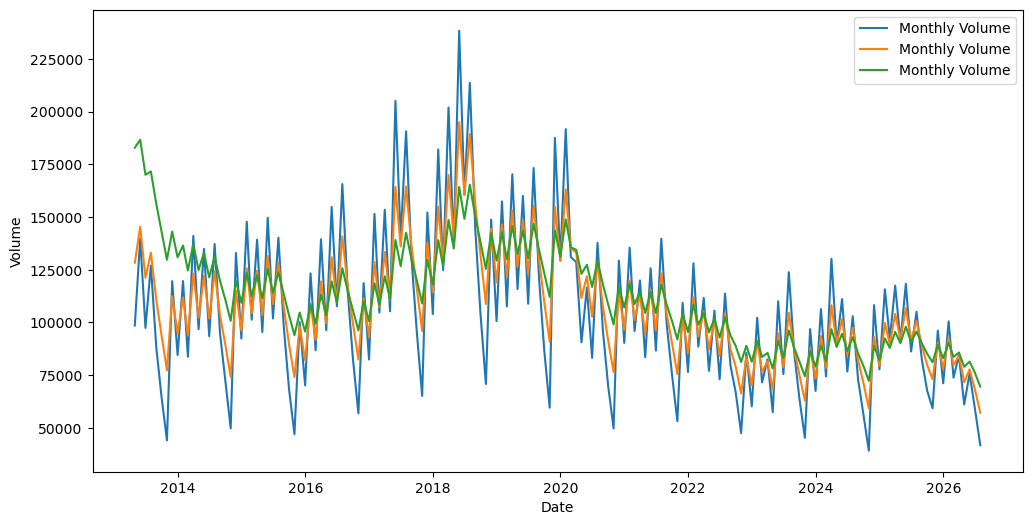

In [44]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data=exp_volume_5,x=exp_volume_5.index,y='Volume',label='Monthly Volume')
sns.lineplot(data=exp_volume_10,x=exp_volume_5.index,y='Volume',label='Monthly Volume')
sns.lineplot(data=exp_volume_20,x=exp_volume_5.index,y='Volume',label='Monthly Volume')

它们的走势近乎相同,如果以在历史上的百分位作为一个因子,可能差不多.

In [45]:
exp_volume_5['pct_rank'] = exp_volume_5['Volume'].rank(pct=True)
exp_volume_10['pct_rank'] = exp_volume_10['Volume'].rank(pct=True)
exp_volume_20['pct_rank'] = exp_volume_20['Volume'].rank(pct=True)
display(exp_volume_5)

,Volume,pct_rank
Date,,
2013-04-30,98548.320084,0.48750
2013-05-31,139734.880056,0.84375
2013-06-30,97402.920038,0.47500
2013-07-31,126991.946692,0.73750
2013-08-31,88163.631128,0.36250
...,...,...
2026-03-31,84340.429154,0.31250
2026-04-30,61100.286103,0.10625
2026-05-31,75769.190735,0.23125


### 步骤二  
#### 找出交易量和黄金价格变化率的关系

In [63]:
gold_pct_change = gold_future['Close'].pct_change()
gold_pct_change = gold_pct_change[gold_pct_change.index >= '2013-04-30']
gold_pct_change = gold_pct_change * 100
gold_pct_change = gold_pct_change.to_frame()
gold_pct_change['Close'] = gold_pct_change['Close'].round(2)
display(gold_pct_change)

,Close
Date,
2013-04-30,0.33
2013-05-01,-1.76
2013-05-02,1.48
2013-05-03,-0.23
2013-05-06,0.26
...,...
2026-07-17,0.68
2026-07-20,-0.06
2026-07-21,1.52


In [64]:
px.line(gold_pct_change, x=gold_pct_change.index, y='Close', title='Gold Future Monthly Percentage Change', labels={'Close': 'Percentage Change (%)', 'index': 'Date'})

由于交易量的间隔时间是月,因此应该先算的是月百分比.

In [79]:
# gold_pct_change = gold_pct_change.to_frame()
gold_pct_change = gold_future['Close'].resample("ME").first().pct_change()
gold_pct_change = gold_pct_change[gold_pct_change.index >= '2013-04-30']
gold_pct_change = gold_pct_change * 100
# gold_pct_change['Close'] = gold_pct_change['Close'].round(2)
display(gold_pct_change)

Date
2013-04-30     1.787644
2013-05-31    -9.606247
2013-06-30    -2.392318
2013-07-31   -11.036334
2013-08-31     4.387290
                ...    
2026-03-31    14.535422
2026-04-30    -9.655480
2026-05-31    -3.204973
2026-06-30    -3.341319
2026-07-31    -9.092334
Freq: ME, Name: Close, Length: 160, dtype: float64

In [84]:
print(gold_pct_change.corr(exp_volume_5['pct_rank']))
print(gold_pct_change.corr(exp_volume_10['pct_rank']))
print(gold_pct_change.corr(exp_volume_20['pct_rank']))

0.04431789052068767
0.004230618420014289
-0.09153794012287741


In [88]:
px.scatter(x=exp_volume_5['pct_rank'], y=gold_pct_change, title='Gold Future Monthly Percentage Change vs. 5-Month Exponential Moving Average Volume', labels={'x': '5-Month Exponential Moving Average Volume Percentile Rank', 'y': 'Gold Future Monthly Percentage Change (%)'},trendline='ols')

In [91]:
px.scatter(x=exp_volume_10['pct_rank'],
           y=gold_pct_change,
           title='Gold Future Monthly Percentage Change vs. 10-Month Exponential Moving Average Volume',
           labels={'x': '10-Month Exponential Moving Average Volume Percentile Rank',
                   'y': 'Gold Future Monthly Percentage Change (%)'},
           trendline='ols')



In [90]:
px.scatter(x=exp_volume_20['pct_rank'],
           y=gold_pct_change,
           title='Gold Future Monthly Percentage Change vs. 20-Month Exponential Moving Average Volume',
           labels={'x': '20-Month Exponential Moving Average Volume Percentile Rank',
                   'y': 'Gold Future Monthly Percentage Change (%)'},
           trendline='ols')

为什么EMA5,10呈现正相关性,而20呈现了负相关性?  


1. span=5
今天	33.3%
昨天	22.2%
前天	14.8%
3天前	9.9%
4天前	6.6%

前5天合计：
约 86.8%

2. span=10
今天	18.2%
昨天	14.9%
前天	12.2%
3天前	10.0%
4天前	8.1%


前5天合计：
约 63.4%

3. span=20
时间	权重
今天	9.5%
昨天	8.6%
前天	7.8%
3天前	7.0%
4天前	6.4%

前5天合计：
约 39.3%  


20的时间权重偏小.应该予以删除.

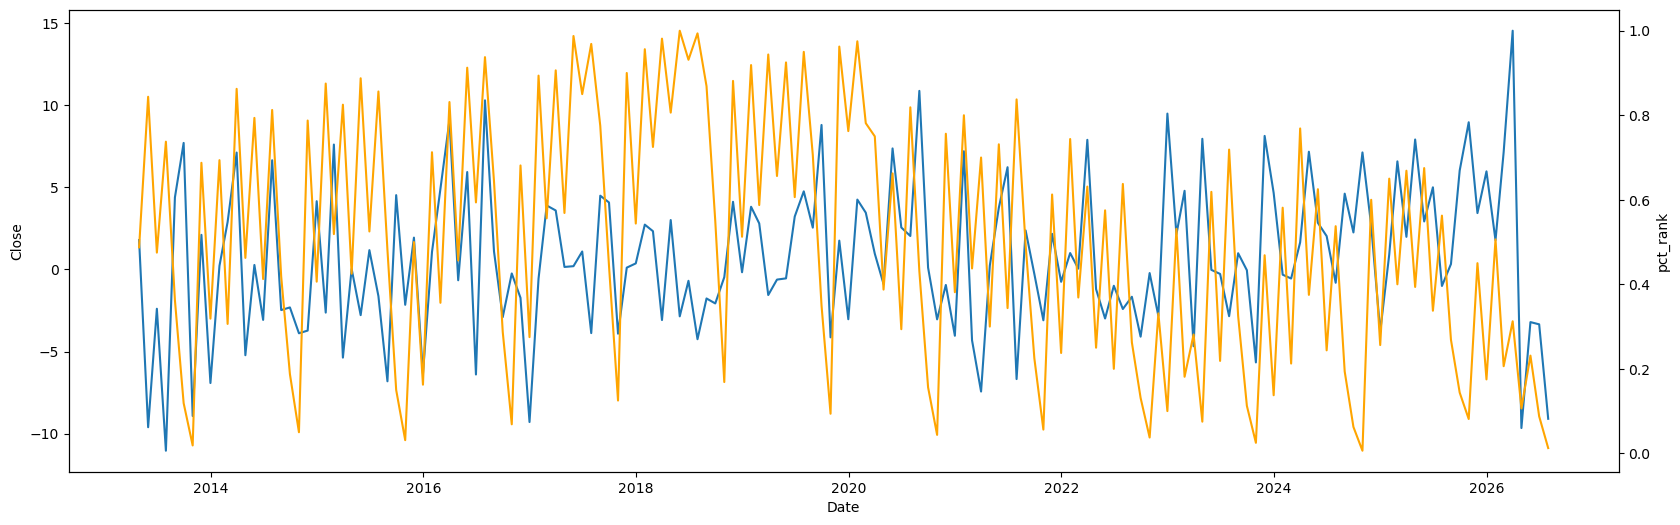

In [101]:
fig, ax1 = plt.subplots(figsize=(20, 6))

sns.lineplot(
    data=gold_pct_change,
    ax=ax1
)

ax2 = ax1.twinx()

sns.lineplot(
    data=exp_volume_5,
    x=exp_volume_5.index,
    y='pct_rank',
    ax=ax2,
    color='orange',
)

plt.show()

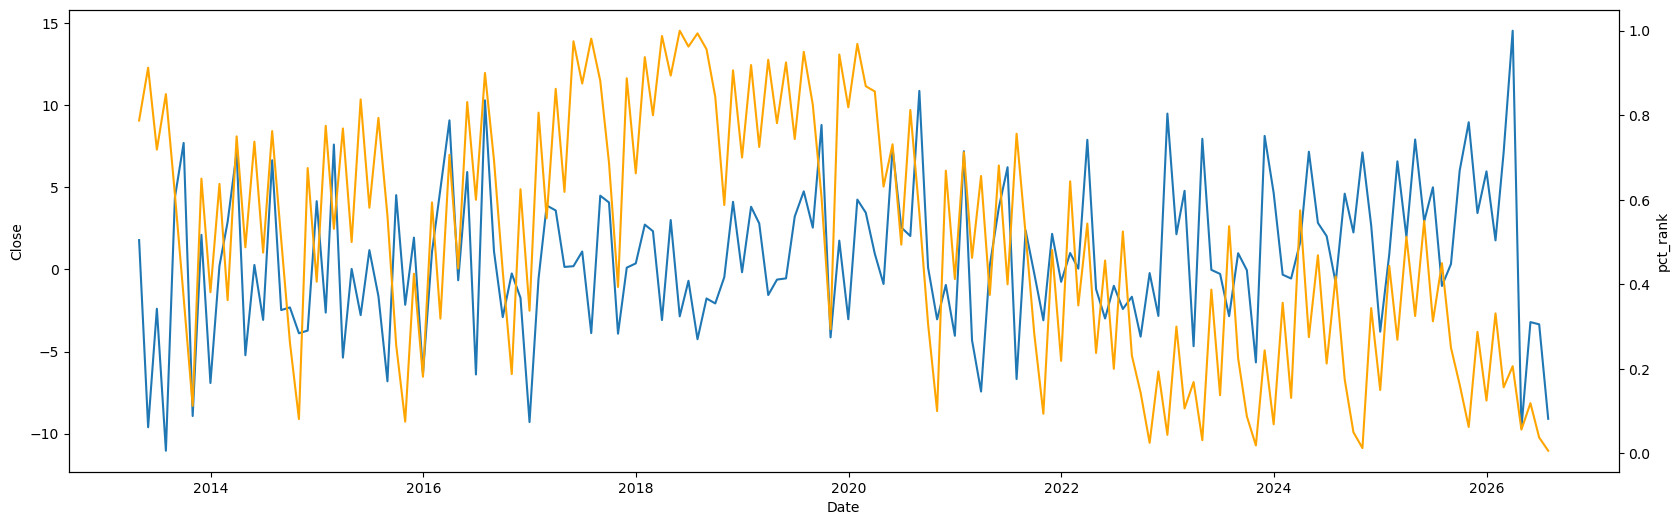

In [102]:
fig, ax1 = plt.subplots(figsize=(20, 6))

sns.lineplot(
    data=gold_pct_change,
    ax=ax1
)

ax2 = ax1.twinx()

sns.lineplot(
    data=exp_volume_10,
    x=exp_volume_10.index,
    y='pct_rank',
    ax=ax2,
    color='orange',
)

plt.show()

由于加权平均中,span=5比span=10,第一个和第二个权重相差更大,而由于主力合约会呈现大小月,所以span=5的波动会更大一些,span=10则第1,2个月的权重相近,一定程度能平滑以下大小月的波动,起到类似于两个月取平均的作用.因此,之后选用EWM_10作为因子更合适一些.但是从线性关系来看,span5的线性关系虽然较弱,但是比span10的相关性更强  
但是从图中来看,虽然span=5与10都是正相关关系,但是5的敏感度更高,成交量活跃对价格涨幅关系更明显一点.之后作为因子,还是要带入到模型中,查看两者真实的差距.

此外,可能随着时代发展,或者阶段性的特点,供需关系可能呈现阶段性的关系.如果我们不以历史上的百分位,而是以滑动窗口间的变化率,即最近几个月相比前一段时间,交易活跃度的变化来找出和金价变化的规律,是否更好一些?  
即,上面是用历史上的情绪来判断,而这里用相对于前段时间的情绪变化来判断.  
可能会由于突发事件,黄金的交易量相对于之前有所提升.这时候应用相对变化而非历史活跃度.

In [103]:
display(exp_volume_5)

,Volume,pct_rank
Date,,
2013-04-30,98548.320084,0.48750
2013-05-31,139734.880056,0.84375
2013-06-30,97402.920038,0.47500
2013-07-31,126991.946692,0.73750
2013-08-31,88163.631128,0.36250
...,...,...
2026-03-31,84340.429154,0.31250
2026-04-30,61100.286103,0.10625
2026-05-31,75769.190735,0.23125


In [104]:
exp_5_pct_change = (exp_volume_5.pct_change() * 100).round(2)
exp_10_pct_change = (exp_volume_10.pct_change() * 100).round(2)
display(exp_5_pct_change)

,Volume,pct_rank
Date,,
2013-04-30,NaN,NaN
2013-05-31,41.79,73.08
2013-06-30,-30.29,-43.70
2013-07-31,30.38,55.26
2013-08-31,-30.58,-50.85
...,...,...
2026-03-31,14.22,51.52
2026-04-30,-27.56,-66.00
2026-05-31,24.01,117.65


In [109]:
px.scatter(x=exp_5_pct_change['Volume'],y=gold_pct_change,title='Gold Future Monthly Percentage Change vs. 5-Month Exponential Moving Average Volume pct',trendline='ols',
            labels={'x': '5-Month Exponential Moving Average Volume pct change',
                   'y': 'Gold Future Monthly Percentage Change (%)'},
           )



In [110]:
px.scatter(x=exp_10_pct_change['Volume'],y=gold_pct_change,title='Gold Future Monthly Percentage Change vs. 10-Month Exponential Moving Average Volume pct',trendline='ols',
            labels={'x': '10-Month Exponential Moving Average Volume pct change',
                   'y': 'Gold Future Monthly Percentage Change (%)'},
           )


首先根据这个图形,发现了问题:  
#### 收益变化的百分率会随着基数改变  
比如10->8,变化率为-20%,
而8->10,变化率为25%,
由于上一次基数较小,下一个月突然增大,会让变化率更偏向大一点的数值,在统计上变化率呈现不对称性.因此我们要采用对数来解决这个问题.  
用百分比变化,容易压缩成交量负向变化,拉伸正向变化,因此应用对数使其对称,减少极端值影响,而本身不会创造出相关性.  
由于最小二乘法的特性,加上比例偏向于拉伸变化,最小二乘法易受极端值影响

In [ ]:
# import numpy as np
# exp_5_pct_change_log = np.log(exp_5_pct_change)
# exp_10_pct_change_log = np.log(exp_10_pct_change)

In [117]:
display(exp_5_pct_change_log)

,Volume,pct_rank
Date,,
2013-04-30,NaN,NaN
2013-05-31,3.732657,4.291555
2013-06-30,NaN,NaN
2013-07-31,3.413784,4.012049
2013-08-31,NaN,NaN
...,...,...
2026-03-31,2.654649,3.941970
2026-04-30,NaN,NaN
2026-05-31,3.178470,4.767714


In [114]:
exp_5_pct_change

,Volume,pct_rank
Date,,
2013-04-30,NaN,NaN
2013-05-31,41.79,73.08
2013-06-30,-30.29,-43.70
2013-07-31,30.38,55.26
2013-08-31,-30.58,-50.85
...,...,...
2026-03-31,14.22,51.52
2026-04-30,-27.56,-66.00
2026-05-31,24.01,117.65


要处理成对数,log(x)中的X必须 **大于0**

In [119]:
exp_5_pct_change = (exp_volume_5/exp_volume_5.shift(1))
exp_10_pct_change = (exp_volume_10/exp_volume_10.shift(1))
display(exp_5_pct_change)

,Volume,pct_rank
Date,,
2013-04-30,NaN,NaN
2013-05-31,1.417933,1.730769
2013-06-30,0.697055,0.562963
2013-07-31,1.303780,1.552632
2013-08-31,0.694246,0.491525
...,...,...
2026-03-31,1.142172,1.515152
2026-04-30,0.724448,0.340000
2026-05-31,1.240079,2.176471


In [120]:
exp_5_pct_change_log = np.log(exp_5_pct_change)
exp_10_pct_change_log = np.log(exp_10_pct_change)
display(exp_5_pct_change_log)

,Volume,pct_rank
Date,,
2013-04-30,NaN,NaN
2013-05-31,0.349200,0.548566
2013-06-30,-0.360891,-0.574541
2013-07-31,0.265267,0.439951
2013-08-31,-0.364929,-0.710242
...,...,...
2026-03-31,0.132932,0.415515
2026-04-30,-0.322345,-1.078810
2026-05-31,0.215175,0.777705


In [ ]:
gold_pct_change = gold_future['Close']/gold_future['Close'].shift(1)


Date
2012-05-09         NaN
2012-05-10    0.000878
2012-05-11   -0.007236
2012-05-14   -0.014630
2012-05-15   -0.002438
                ...   
2026-07-17    0.006776
2026-07-20   -0.000598
2026-07-21    0.015047
2026-07-22    0.018448
2026-07-23   -0.024484
Name: Close, Length: 3570, dtype: float64

In [127]:
# gold_pct_change = gold_future['Close'].resample("ME").first()
# gold_pct_change = gold_pct_change[gold_pct_change.index >= '2013-04-30']
# gold_pct_change = gold_pct_change/gold_pct_change.shift(1)
gold_pct_change_log = np.log(gold_pct_change)
display(gold_pct_change_log)

Date
2013-04-30         NaN
2013-05-31   -0.100995
2013-06-30   -0.024214
2013-07-31   -0.116942
2013-08-31    0.042938
                ...   
2026-03-31    0.135714
2026-04-30   -0.101540
2026-05-31   -0.032575
2026-06-30   -0.033984
2026-07-31   -0.095326
Freq: ME, Name: Close, Length: 160, dtype: float64

In [128]:
px.scatter(x=exp_5_pct_change_log['Volume'],y=gold_pct_change_log,title='Gold Future Monthly Percentage Change vs. 5-Month Exponential Moving Average Volume pct',trendline='ols',
            labels={'x': '5-Month Exponential Moving Average Volume pct change',
                   'y': 'Gold Future Monthly Percentage Change (%)'},
           )

In [131]:
display(exp_5_pct_change_log['Volume'].corr(gold_pct_change_log))
display(exp_5_pct_change['Volume'].corr(gold_pct_change))

np.float64(0.04604544609253183)

np.float64(0.04155508525327586)

从线性关系来看,log后仅仅提高了一点线性关系,但还是很弱.  
从结果来看,用历史的百分比与成交量相对变化,他们的线性关系最高只有0.04,关系很弱.

### 提出问题

#### 问题一  
从图中也看不出来非线性关系,进行 **分组** 查看是否交易量上涨和价格上升有更显著的相关性,因为炒股中经常以 **量价齐升** 作为一个判断标准.

#### 问题二  
因为期货是看期望的,是否我拿当月相比于上个月的涨幅跟这个月的交易量探索,是不对的呢?我应该寻找交易量和未来黄金上涨的关系.

---

In [134]:
exp_5_pct_change_log_pos = exp_5_pct_change_log[exp_5_pct_change_log['Volume'] > 0]
px.scatter(x=exp_5_pct_change_log_pos['Volume'],y=gold_pct_change_log.loc[exp_5_pct_change_log_pos.index],title='Gold Future Monthly Percentage Change vs. 5-Month Exponential Moving Average Volume pct (Positive Changes)',trendline='ols',)

In [135]:
print(exp_5_pct_change_log_pos['Volume'].corr(gold_pct_change_log.loc[exp_5_pct_change_log_pos.index]))

0.06620267478616061


当选择交易量上涨的时候,其线性关系提升了一些,但是仍然不太显著.量价齐升的观点似乎不太适用于黄金期货

In [136]:
px.scatter(x=exp_5_pct_change_log['Volume'],y=abs(gold_pct_change_log),title='Gold Future Monthly Percentage Change Absolutevs. 5-Month Exponential Moving Average Volume pct',trendline='ols',
            labels={'x': '5-Month Exponential Moving Average Volume pct change',
                   'y': 'Gold Future Monthly Percentage Change (%)'},
           )

用绝对值查看不同波动率下的黄金变化,似乎呈现某种趋势,进行分组观察,分成0,0-0,6,0.6三个组,求它们的平均波动率.

In [151]:
abs_gold_pct_change_log = abs(gold_pct_change_log)
volume_group = pd.cut(
    exp_5_pct_change_log['Volume'],
    bins=[-np.inf,0,0.6,np.inf],
    labels=['Negative Changes','0-82% Changes','Positive Changes']
)

In [152]:
abs_gold_pct_change_log_grouped = abs_gold_pct_change_log.groupby(volume_group).mean()
display(abs_gold_pct_change_log_grouped)

/var/folders/nm/mph7gkl57w5_rd8w9fgp9c5r0000gp/T/ipykernel_1751/1037634074.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



Volume
Negative Changes    0.036508
0-82% Changes       0.040034
Positive Changes    0.021255
Name: Close, dtype: float64

从中得到,相对而言,交易量温和上涨时波动率相对最大,下降时波动率有所下降.大于82%的涨幅可能由于数据过少,呈现较小的波动率.

#### 结论一  
交易量上涨和黄金价格走高,在当月的正相关性很弱.交易量上升与黄金价格可能没有本质关系.